# Load Data

In [116]:
import polars as pl

df = pl.scan_parquet("/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/training_truncated_data_codex.parquet")
print(df.head(1).collect())



shape: (1, 77)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ cutoff_ti ┆ journey_t ┆ journey_t ┆ … ┆ count_ed_ ┆ seen_ed_2 ┆ count_ed_ ┆ seen_ed_ │
│ ---       ┆ me        ┆ erminal_t ┆ erminal_r ┆   ┆ 29        ┆ 9         ┆ 37        ┆ 37       │
│ str       ┆ ---       ┆ ime       ┆ eason     ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ datetime[ ┆ ---       ┆ ---       ┆   ┆ i64       ┆ bool      ┆ i64       ┆ bool     │
│           ┆ μs, UTC]  ┆ datetime[ ┆ str       ┆   ┆           ┆           ┆           ┆          │
│           ┆           ┆ μs, UTC]  ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ -19698103 ┆ 2021-10-1 ┆ 2022-04-0 ┆ inactive_ ┆ … ┆ 0         ┆ false     ┆ 0         ┆ false    │
│ 8 -170292 ┆ 8 03:43:1 ┆ 2         ┆ 60d       ┆   ┆           ┆           

In [88]:
df.columns

/var/folders/69/ysm8yfcn76s_32xvcxfbp8s00000gn/T/ipykernel_99639/3289350417.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  df.columns


['id',
 'cutoff_time',
 'journey_terminal_time',
 'journey_terminal_reason',
 'label_order_shipped',
 'sampling_weight_days',
 'n_events_observed',
 'n_unique_event_types_observed',
 'observed_duration_days',
 'days_since_last_event',
 'cutoff_hour_utc',
 'cutoff_dayofweek_utc',
 'cutoff_month_utc',
 'cutoff_dayofyear_utc',
 'first_ed_id',
 'first_event_name',
 'first_stage',
 'last_ed_id',
 'last_event_name',
 'last_stage',
 'max_milestone_seen',
 'count_ed_2',
 'seen_ed_2',
 'count_ed_3',
 'seen_ed_3',
 'count_ed_4',
 'seen_ed_4',
 'count_ed_5',
 'seen_ed_5',
 'count_ed_6',
 'seen_ed_6',
 'count_ed_7',
 'seen_ed_7',
 'count_ed_8',
 'seen_ed_8',
 'count_ed_9',
 'seen_ed_9',
 'count_ed_10',
 'seen_ed_10',
 'count_ed_11',
 'seen_ed_11',
 'count_ed_12',
 'seen_ed_12',
 'count_ed_13',
 'seen_ed_13',
 'count_ed_14',
 'seen_ed_14',
 'count_ed_15',
 'seen_ed_15',
 'count_ed_16',
 'seen_ed_16',
 'count_ed_17',
 'seen_ed_17',
 'count_ed_18',
 'seen_ed_18',
 'count_ed_19',
 'seen_ed_19',
 'coun

# Modeling

## XGBoost

In [89]:
import polars as pl
import xgboost as xgb
import pyarrow.dataset as ds

class PolarsDataIter(xgb.core.DataIter):
    def __init__(self, file_path, features, label, weight=None, batch_size=200_000):
        self.file_path = file_path
        self.features = features
        self.label = label
        self.weight = weight
        self.batch_size = batch_size
        self._it = None
        super().__init__()

    def reset(self):
        dataset = ds.dataset(self.file_path, format="parquet")
        cols_to_load = self.features + [self.label]
        if self.weight:
            cols_to_load.append(self.weight)
            
        self._it = dataset.to_batches(
            batch_size=self.batch_size,
            columns=cols_to_load
        )

    def next(self, input_data):
        try:
            batch = next(self._it)
            df = pl.from_arrow(batch)
            
            # 1. Handle Categoricals + Timestamps
            for col_name in df.columns:
                dtype = df.schema[col_name]
                
                # Convert Strings to Categorical, then to their physical Integer IDs
                # This locks the IDs so they don't drift between Pass 1 and Pass 2
                if dtype in [pl.String, pl.Utf8]:
                    df = df.with_columns(
                        pl.col(col_name).cast(pl.Categorical).to_physical().cast(pl.Int32)
                    )
                
                # Handle Timestamps (the previous error)
                elif dtype in [pl.Datetime, pl.Date]:
                    df = df.with_columns(pl.col(col_name).cast(pl.Int64))
            
            X = df.select(self.features)
            y = df.get_column(self.label)
            
            kwargs = {'data': X, 'label': y}
            if self.weight:
                kwargs['weight'] = df.get_column(self.weight)
                
            input_data(**kwargs)
            return True
        except StopIteration:
            return False

# --- Training Setup ---

file_path = "/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/training_truncated_data_codex.parquet"
label_col = "label_order_shipped"  # <--- Change this to your actual label name
weight_col = "sampling_weight_days"               # <--- Change this if you have a weight column

# 2. Extract all column names from the Parquet schema
dataset = ds.dataset(file_path, format="parquet")
all_columns = dataset.schema.names

# --- Updated Feature Selection ---

# Columns that effectively tell the model the answer (Data Leakage)
leakage_cols = [
    "journey_terminal_reason", 
    "journey_terminal_time",
    "cutoff_time", # Sometimes cutoff_time can leak info depending on how it's used
    "id"           # Always drop IDs
]

# Filter out the label, weight, and the leaky columns

#features = [
#    col for col in all_columns 
#   if col not in [label_col, weight_col] + leakage_cols
#]

features = ['n_events_observed', 'n_unique_event_types_observed', 'observed_duration_days', 'days_since_last_event', 'cutoff_hour_utc']

print(f"Number of clean features: {len(features)}")

# 4. Now pass 'features' into your iterator
data_iterator = PolarsDataIter(
    file_path=file_path,
    features=features,
    label=label_col,
    weight=weight_col,
    batch_size=200_000
)

with pl.StringCache():
    # Only pass the iterator and the enable_categorical flag.
    # Do NOT pass label=..., weight=..., or feature_types=... here.
    dtrain = xgb.QuantileDMatrix(
        data=data_iterator, 
        enable_categorical=True
    )

    params = {
        'objective': 'binary:logistic',
        'tree_method': 'hist',
        'enable_categorical': True,
        'eval_metric': 'auc'
    }

    model = xgb.train(params, dtrain, num_boost_round=100)

Number of clean features: 5


/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/.m148/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [11:48:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "enable_categorical" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [90]:
threshold = 0.5

In [91]:
import numpy as np

all_probs = []
all_labels = []

data_iterator.reset()

# We use a dummy callback to extract data from the iterator batches
def get_prediction(data, label, **kwargs):
    # DMatrix for inference doesn't need Quantile logic
    dtest_batch = xgb.DMatrix(data, enable_categorical=True)
    batch_probs = model.predict(dtest_batch)
    
    all_probs.append(batch_probs)
    all_labels.append(label.to_numpy())

print("Predicting on test data...")
while data_iterator.next(get_prediction):
    pass

# Combine batch results into single arrays
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_labels)
y_pred = (y_probs > threshold).astype(int)

print(f"Predictions complete for {len(y_probs):,} rows.")

Predicting on test data...
Predictions complete for 1,430,445 rows.


--- RAW CONFUSION MATRIX COUNTS ---
                        Predicted Not Shipped (0)  Predicted Shipped (1)
Actual Not Shipped (0)                    1148609                   2473
Actual Shipped (1)                         198004                  81359


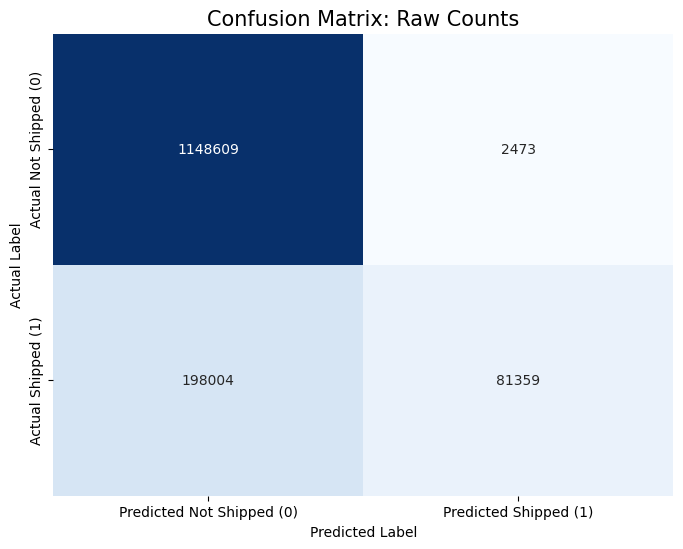

In [92]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Generate the raw confusion matrix (counts)
# labels=[0, 1] ensures the order is [Not Shipped, Shipped]
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# 2. Convert to a DataFrame for better labeling in the plot
cm_df = pd.DataFrame(
    cm, 
    index=['Actual Not Shipped (0)', 'Actual Shipped (1)'],
    columns=['Predicted Not Shipped (0)', 'Predicted Shipped (1)']
)

print("--- RAW CONFUSION MATRIX COUNTS ---")
print(cm_df)

# 3. Visualize it
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Raw Counts', fontsize=15)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [93]:
df.select(pl.col("journey_terminal_reason").value_counts()).unnest("journey_terminal_reason").collect()
# 300,000 successes
# 1.15M failures


journey_terminal_reason,count
str,u32
"""inactive_60d""",1151082
"""success""",279363


/var/folders/69/ysm8yfcn76s_32xvcxfbp8s00000gn/T/ipykernel_99639/3873844114.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


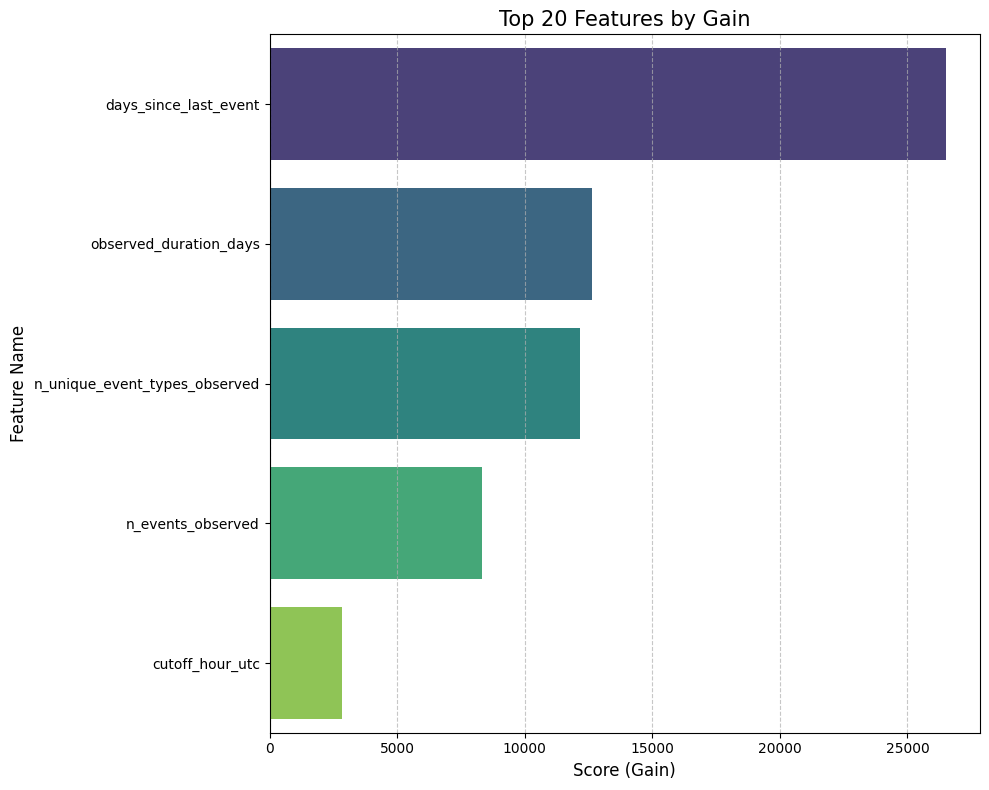

dict_keys(['n_events_observed', 'n_unique_event_types_observed', 'observed_duration_days', 'days_since_last_event', 'cutoff_hour_utc'])


In [94]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Extract importance scores from the model
# 'gain' is the average improvement in accuracy brought by a feature to the branches it is on
importance_type = 'gain'
scores = model.get_score(importance_type=importance_type)

# 2. Convert to a sorted DataFrame for easier plotting
importance_df = pd.DataFrame({
    'Feature': list(scores.keys()),
    'Importance': list(scores.values())
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20), 
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

plt.title(f'Top 20 Features by {importance_type.capitalize()}', fontsize=15)
plt.xlabel(f'Score ({importance_type.capitalize()})', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
print(scores.keys())

### XGBoost Model Evaluation

In [95]:
test_path = "/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/testing_truncated_data_codex.parquet"
df_test = pl.scan_parquet(test_path)
df_test.head().collect()

id,cutoff_time,journey_terminal_time,journey_terminal_reason,label_order_shipped,sampling_weight_days,n_events_observed,n_unique_event_types_observed,observed_duration_days,days_since_last_event,cutoff_hour_utc,cutoff_dayofweek_utc,cutoff_month_utc,cutoff_dayofyear_utc,first_ed_id,first_event_name,first_stage,last_ed_id,last_event_name,last_stage,max_milestone_seen,count_ed_2,seen_ed_2,count_ed_3,seen_ed_3,count_ed_4,seen_ed_4,count_ed_5,seen_ed_5,count_ed_6,seen_ed_6,count_ed_7,seen_ed_7,count_ed_8,seen_ed_8,count_ed_9,seen_ed_9,…,seen_ed_11,count_ed_12,seen_ed_12,count_ed_13,seen_ed_13,count_ed_14,seen_ed_14,count_ed_15,seen_ed_15,count_ed_16,seen_ed_16,count_ed_17,seen_ed_17,count_ed_18,seen_ed_18,count_ed_19,seen_ed_19,count_ed_20,seen_ed_20,count_ed_21,seen_ed_21,count_ed_22,seen_ed_22,count_ed_23,seen_ed_23,count_ed_25,seen_ed_25,count_ed_26,seen_ed_26,count_ed_27,seen_ed_27,count_ed_28,seen_ed_28,count_ed_29,seen_ed_29,count_ed_37,seen_ed_37
str,"datetime[μs, UTC]","datetime[μs, UTC]",str,i64,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,str,str,i64,str,str,f64,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,…,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool,i64,bool
"""-1181762664 1156176889""",2023-01-11 19:00:07.464619 UTC,2023-03-22 01:19:21 UTC,"""inactive_60d""",0,104,105,7,33.769913,17.353026,19,2,1,11,12,"""application_web_approved""","""Apply for Credit""",4,"""browse_products""","""First Purchase""",1.0,1,true,0,false,53,true,25,true,7,true,0,false,0,false,0,false,…,true,1,true,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false
"""894910161 728629887""",2023-01-21 18:19:55.430757 UTC,2023-02-15 12:08:33 UTC,"""inactive_60d""",0,61,14,6,35.288431,35.257899,18,5,1,21,19,"""application_web_view""","""Apply for Credit""",1,null,null,1.0,0,false,1,true,3,true,0,false,0,false,0,false,0,false,0,false,…,true,1,true,0,false,0,false,0,false,0,false,0,false,0,false,7,true,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false
"""-2031918852 -1135485949""",2023-01-19 13:56:50.747344 UTC,2023-03-05 13:31:45 UTC,"""inactive_60d""",0,122,111,13,76.063828,15.017428,13,3,1,19,19,"""application_web_view""","""Apply for Credit""",1,null,null,5.0,0,false,3,true,40,true,15,true,7,true,1,true,1,true,0,false,…,true,1,true,0,false,0,false,0,false,0,false,0,false,0,false,24,true,0,false,0,false,0,false,0,false,0,false,0,false,1,true,0,false,1,true,0,false
"""1863147845 -1106736852""",2023-01-30 01:35:26.583551 UTC,2023-02-10 01:47:53 UTC,"""inactive_60d""",0,65,35,4,53.623467,48.991361,1,0,1,30,19,"""application_web_view""","""Apply for Credit""",4,"""browse_products""","""First Purchase""",1.0,0,false,2,true,22,true,0,false,0,false,0,false,0,false,0,false,…,false,1,true,0,false,0,false,0,false,0,false,0,false,0,false,10,true,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false,0,false
"""-1240179938 -1309231010""",2022-12-30 13:46:32.766073 UTC,2023-02-03 23:17:43 UTC,"""inactive_60d""",0,61,14,5,24.854233,24.603354,13,4,12,364,19,"""application_web_view""","""Apply for Credit""",22,"""pre_application_3rd_party_affi…","""Discover""",1.0,1,true,1,true,0,false,0,false,0,false,0,false,0,false,0,false,…,false,1,true,0,false,0,false,0,false,0,false,0,false,0,false,10,true,0,false,0,false,1,true,0,false,0,false,0,false,0,false,0,false,0,false,0,false


In [96]:
# Initialize a NEW iterator for the test data
test_iterator = PolarsDataIter(
    file_path=test_path,
    features=features, # MUST be the same list from training
    label=label_col,
    weight=weight_col,
    batch_size=200_000
)

In [97]:
import numpy as np

all_probs = []
all_labels = []

test_iterator.reset()

# We use a dummy callback to extract data from the iterator batches
def get_prediction(data, label, **kwargs):
    # DMatrix for inference doesn't need Quantile logic
    dtest_batch = xgb.DMatrix(data, enable_categorical=True)
    batch_probs = model.predict(dtest_batch)
    
    all_probs.append(batch_probs)
    all_labels.append(label.to_numpy())

print("Predicting on test data...")
while test_iterator.next(get_prediction):
    pass

# Combine batch results into single arrays
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_labels)
y_pred = (y_probs > threshold).astype(int)

print(f"Predictions complete for {len(y_probs):,} rows.")

Predicting on test data...
Predictions complete for 158,325 rows.


In [98]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

print(f"\nTest AUC Score: {roc_auc_score(y_true, y_probs):.4f}")
print("\nTest Classification Report:")
print(classification_report(y_true, y_pred))


Test AUC Score: nan

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    158325
           1       0.00      0.00      0.00         0

    accuracy                           1.00    158325
   macro avg       0.50      0.50      0.50    158325
weighted avg       1.00      1.00      1.00    158325



/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/.m148/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/.m148/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/emiliodulay/Documents/1. UCLA/2. Year 2/3. Spring 2026/STAT M148/statM148proj/.m148/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

/var/folders/69/ysm8yfcn76s_32xvcxfbp8s00000gn/T/ipykernel_99639/3873844114.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


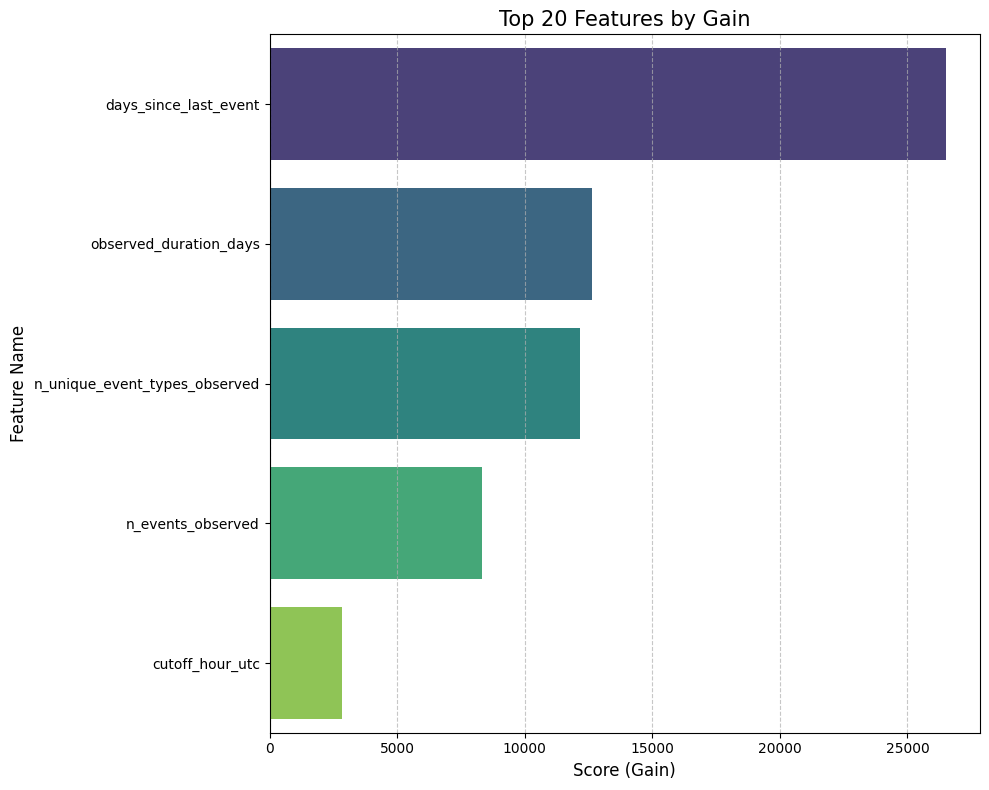

dict_keys(['n_events_observed', 'n_unique_event_types_observed', 'observed_duration_days', 'days_since_last_event', 'cutoff_hour_utc'])


In [99]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Extract importance scores from the model
# 'gain' is the average improvement in accuracy brought by a feature to the branches it is on
importance_type = 'gain'
scores = model.get_score(importance_type=importance_type)

# 2. Convert to a sorted DataFrame for easier plotting
importance_df = pd.DataFrame({
    'Feature': list(scores.keys()),
    'Importance': list(scores.values())
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20), 
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

plt.title(f'Top 20 Features by {importance_type.capitalize()}', fontsize=15)
plt.xlabel(f'Score ({importance_type.capitalize()})', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
print(scores.keys())

Calculating ICE and PDP values...


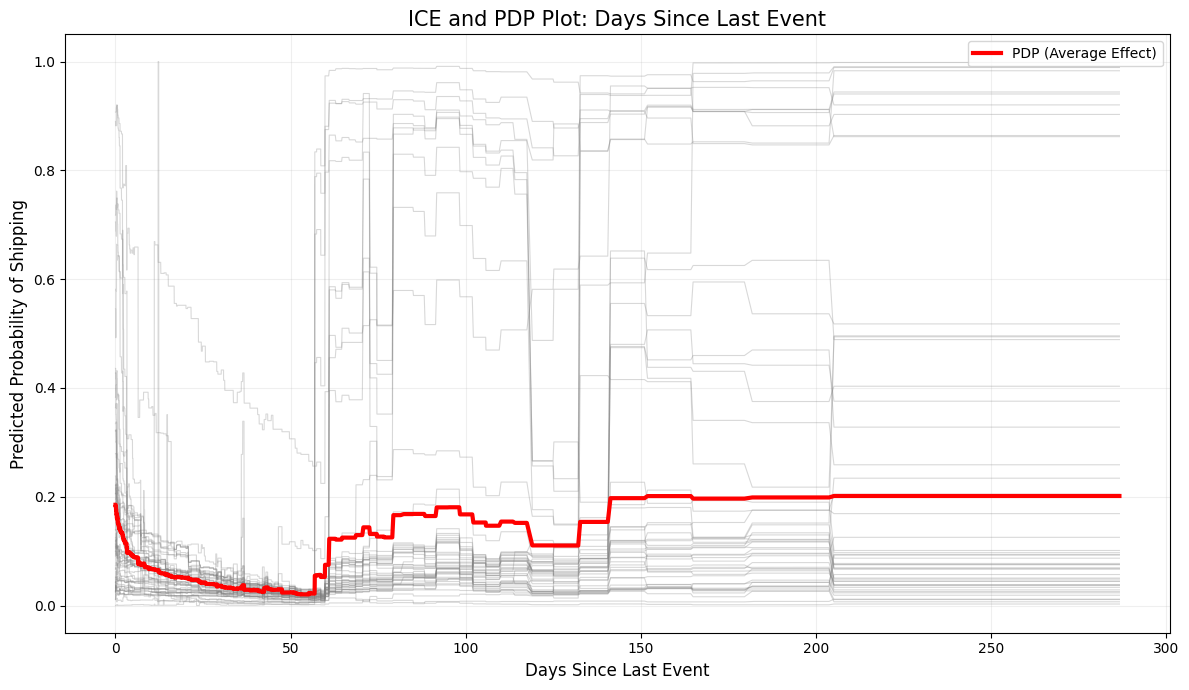

In [100]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# 1. Get a representative sample
sample_df = pl.scan_parquet(file_path).head(10000).collect()

# Preprocessing (Same as previous steps)
for col in sample_df.columns:
    if sample_df.schema[col] in [pl.String, pl.Utf8]:
        sample_df = sample_df.with_columns(pl.col(col).cast(pl.Categorical).to_physical().cast(pl.Int32))
    elif sample_df.schema[col] in [pl.Datetime, pl.Date]:
        sample_df = sample_df.with_columns(pl.col(col).cast(pl.Int64))

# 2. Setup ranges
milestone_range = sorted(sample_df["days_since_last_event"].drop_nulls().unique().to_list())
num_ice_lines = 50  # We will plot 50 individual journey paths
ice_indices = np.random.choice(len(sample_df), num_ice_lines, replace=False)

# Matrix to store all predictions: (Rows in sample x Number of milestones)
ice_matrix = np.zeros((len(sample_df), len(milestone_range)))

print("Calculating ICE and PDP values...")

for i, val in enumerate(milestone_range):
    temp_df = sample_df.with_columns(pl.lit(val).alias("days_since_last_event"))
    X_temp = temp_df.select(features)
    dmatrix_temp = xgb.DMatrix(X_temp, enable_categorical=True)
    
    # Store predictions for every row at this milestone level
    ice_matrix[:, i] = model.predict(dmatrix_temp)

# Calculate PDP (the average of all ICE lines)
pdp_values = np.mean(ice_matrix, axis=0)

# 3. Plotting
plt.figure(figsize=(12, 7))

# Plot Individual ICE lines (thin and transparent)
for idx in ice_indices:
    plt.plot(milestone_range, ice_matrix[idx, :], color='gray', alpha=0.3, linewidth=0.8)

# Plot the PDP line (thick and bold)
plt.plot(milestone_range, pdp_values, color='red', linewidth=3, label='PDP (Average Effect)')

plt.title('ICE and PDP Plot: Days Since Last Event', fontsize=15)
plt.xlabel('Days Since Last Event', fontsize=12)
plt.ylabel('Predicted Probability of Shipping', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

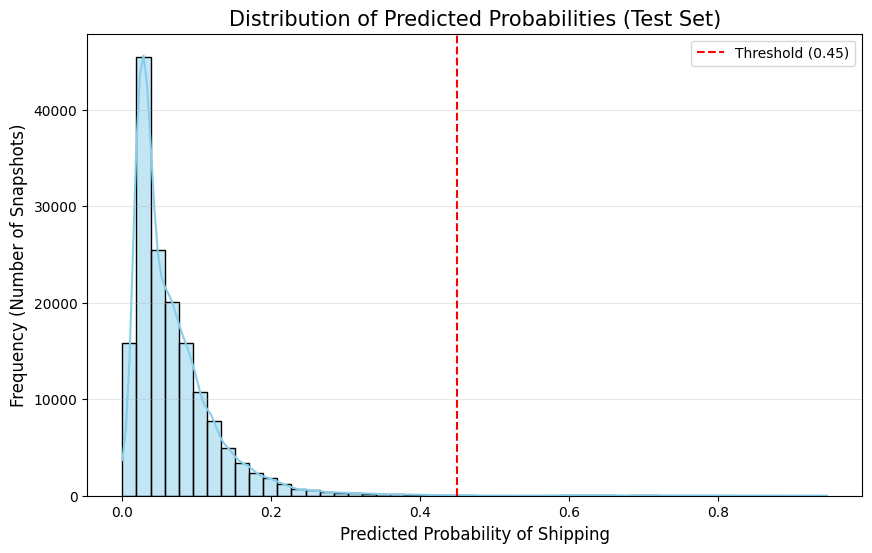

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plotting the distribution of predicted probabilities
sns.histplot(y_probs, bins=50, kde=True, color='skyblue', edgecolor='black')

# Add a vertical line for your specific threshold (0.45)
plt.axvline(x=0.45, color='red', linestyle='--', label='Threshold (0.45)')

plt.title('Distribution of Predicted Probabilities (Test Set)', fontsize=15)
plt.xlabel('Predicted Probability of Shipping', fontsize=12)
plt.ylabel('Frequency (Number of Snapshots)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

## RNN

ValueError: Input X contains NaN.
LinearDiscriminantAnalysis does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# Test File for Submission:

In [102]:
test_ids = pl.scan_parquet(test_path).select("id").collect().get_column("id")

submission = pl.DataFrame({
    "id": test_ids,
    "label_order_shipped": y_pred  # Kaggle usually wants the probability
})

submission.write_csv("kaggle_submission.csv")

print(f"Successfully saved {len(submission):,} predictions to kaggle_submission.csv")

Successfully saved 158,325 predictions to kaggle_submission.csv
